In [6]:
import math as m
import os, sys
import numpy as np
import argparse
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')
import csv

import MDAnalysis as mda
# from MDAnalysis.tests.datafiles import TPR, XTC
from MDAnalysis import transformations
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
from MDAnalysis.transformations import wrap, unwrap
import nglview as nv

In [2]:
%%bash
pwd
ls -ltr

/project/riteshk/riteshk/byteff2/example/FCether-LMB_KHW
total 20
-rw-rw-r-- 1 riteshk pi-riteshk   364 Dec 22 16:08 result_PFP.json
-rw-rw-r-- 1 riteshk pi-riteshk   365 Dec 22 16:08 result_SFB.json
-rw-rw-r-- 1 riteshk pi-riteshk   362 Dec 22 16:08 result_TFE.json
-rw-rw-r-- 1 riteshk pi-riteshk 16131 Dec 26 18:04 ia_id_from_mdanalysis.py
-rwxrwxr-x 1 riteshk pi-riteshk   650 Dec 26 18:18 calc_Ia_Id.sh
drwxrwsr-x 6 riteshk pi-riteshk  4096 Jan  7 22:38 DFETHF
drwxrwsr-x 6 riteshk pi-riteshk  4096 Jan  7 22:46 SFBTHF
drwxrwsr-x 7 riteshk pi-riteshk  4096 Jan  7 22:53 PFPTHF
drwxrwsr-x 6 riteshk pi-riteshk  4096 Jan  7 22:57 TFETHF


In [3]:
os.chdir('/project/riteshk/riteshk/byteff2/example/FCether-LMB_KHW/DFETHF')

### Define MDAnalysis universe and required residue names

In [4]:
u_0 = mda.Universe('transport_working_dir/solvent_salt.gro', 'nvt.dcd')
u_0

/project/riteshk/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


<Universe with 11650 atoms>

In [4]:
u_0.trajectory[0]
u_0.residues.residues[-1].atoms[4]

<Atom 11646: F5 of type F of resname FSI, resid 695 and segid SYSTEM>

In [5]:
# for atom in u_0.residues.residues[-1].atoms:
for atom in u_0.residues.residues[0].atoms:
    print(atom)

<Atom 1: C1 of type C of resname DFETH, resid 1 and segid SYSTEM>
<Atom 2: C2 of type C of resname DFETH, resid 1 and segid SYSTEM>
<Atom 3: C3 of type C of resname DFETH, resid 1 and segid SYSTEM>
<Atom 4: C4 of type C of resname DFETH, resid 1 and segid SYSTEM>
<Atom 5: O5 of type O of resname DFETH, resid 1 and segid SYSTEM>
<Atom 6: O6 of type O of resname DFETH, resid 1 and segid SYSTEM>
<Atom 7: C7 of type C of resname DFETH, resid 1 and segid SYSTEM>
<Atom 8: C8 of type C of resname DFETH, resid 1 and segid SYSTEM>
<Atom 9: F9 of type F of resname DFETH, resid 1 and segid SYSTEM>
<Atom 10: F10 of type F of resname DFETH, resid 1 and segid SYSTEM>
<Atom 11: H11 of type H of resname DFETH, resid 1 and segid SYSTEM>
<Atom 12: H12 of type H of resname DFETH, resid 1 and segid SYSTEM>
<Atom 13: H13 of type H of resname DFETH, resid 1 and segid SYSTEM>
<Atom 14: H14 of type H of resname DFETH, resid 1 and segid SYSTEM>
<Atom 15: H15 of type H of resname DFETH, resid 1 and segid SYSTEM

In [12]:
li = u_0.atoms.select_atoms("resname LI")
salt = u_0.atoms.select_atoms("resname FSI and name O* F*")
salt_F = u_0.atoms.select_atoms("resname FSI and name F*")
solv_O1 = u_0.atoms.select_atoms("resname DFETH and name O5") #cyclic
solv_O2 = u_0.atoms.select_atoms("resname DFETH and name O6") #linear
solv_O = u_0.atoms.select_atoms("resname DFETH and name O*")
solv_F = u_0.atoms.select_atoms("resname DFETH and name F*")
solv_F1 = u_0.atoms.select_atoms("resname DFETH and name F9")
solv_F2 = u_0.atoms.select_atoms("resname DFETH and name F10")
solv = u_0.atoms.select_atoms("resname DFETH and name O* F*")
#solv_F1 = u_0.atoms.select_atoms("resname 3df and name F1")
#solv_F2 = u_0.atoms.select_atoms("resname 3df and name F2")
solv_O

<AtomGroup with 1090 atoms>

### RDF between solvent & Li+

In [13]:
rdf_solv = InterRDF(li, solv, nbins=500)
rdf_solv.run()

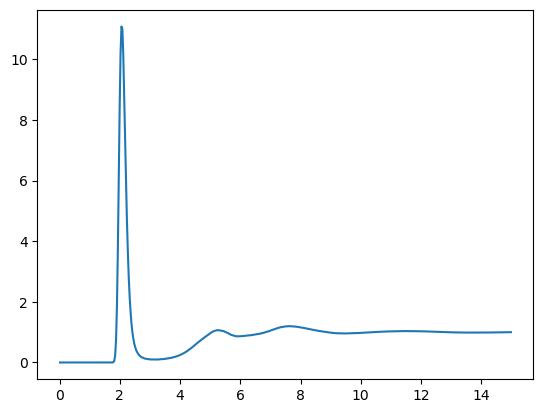

In [14]:
graph = plt.plot(rdf_solv.results.bins, rdf_solv.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]]) 

### RDF between solvent-O & Li+

In [15]:
rdf_solv_O = InterRDF(li, solv_O, nbins=500)
rdf_solv_O.run()

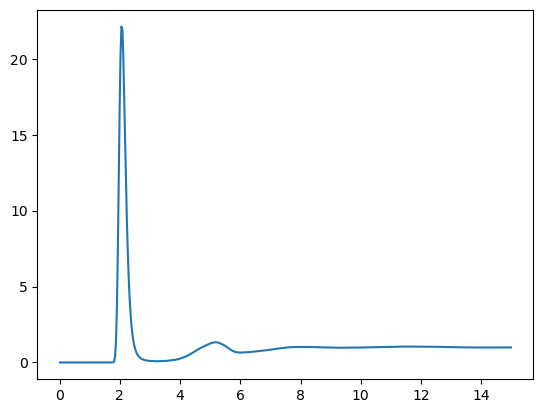

In [16]:
graph = plt.plot(rdf_solv_O.results.bins, rdf_solv_O.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv_O.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

In [17]:
peaks, _  = find_peaks(-rdf_solv_O.results.rdf, distance=5)
rdf_solv_O.results.bins[peaks[0]] ## cut-off for anion

3.255

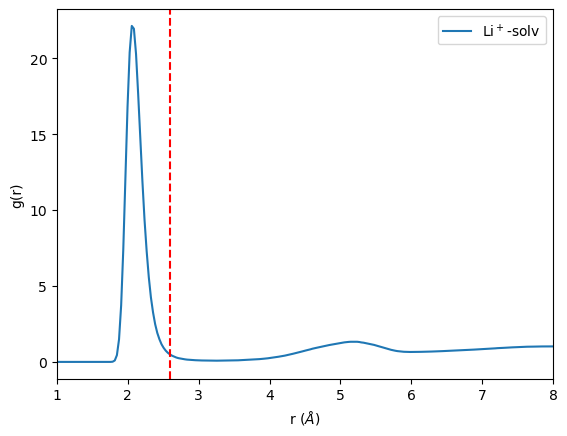

In [18]:
plt.plot(rdf_solv_O.results.bins, rdf_solv_O.results.rdf, label='Li$^+$-solv')
plt.xlim([1,8])
# plt.axvline(x=rdf_solv_O.results.bins[peaks[0]], color='red', linestyle='--')
plt.axvline(x=2.60, color='red', linestyle='--')
plt.xlabel('r ($\AA$)')
plt.ylabel('g(r)')
plt.legend()

In [19]:
rdf_solv_O1 = InterRDF(li, solv_O1, nbins=500)
rdf_solv_O1.run()

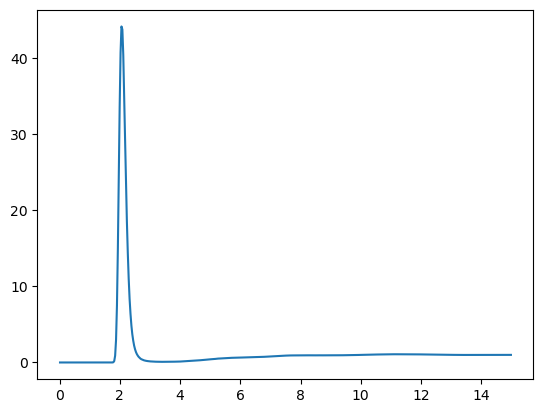

In [20]:
graph = plt.plot(rdf_solv_O1.results.bins, rdf_solv_O1.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv_O1.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])

In [21]:
rdf_solv_O2 = InterRDF(li, solv_O2, nbins=500)
rdf_solv_O2.run()

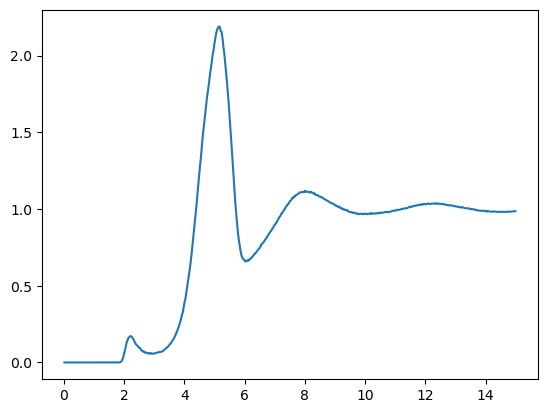

In [22]:
graph = plt.plot(rdf_solv_O2.results.bins, rdf_solv_O2.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv_O2.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])

### RDF between solvent-F & Li+

In [23]:
len(solv_F.residues.resnames)

545

In [24]:
rdf_solv_F = InterRDF(li, solv_F, nbins=500)
rdf_solv_F.run()

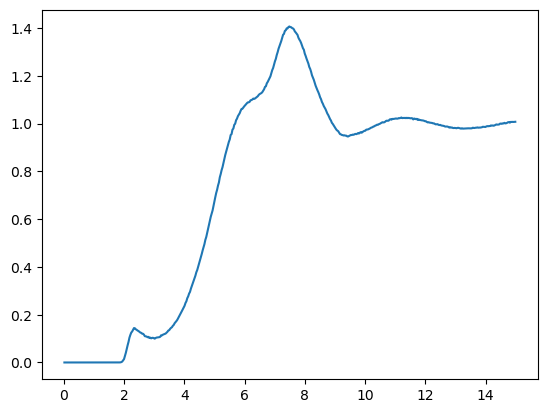

In [25]:
graph = plt.plot(rdf_solv_F.results.bins, rdf_solv_F.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv_F.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

In [26]:
rdf_solv_F_norm = InterRDF(li, solv_F, nbins=500, norm='density')
rdf_solv_F_norm.run()

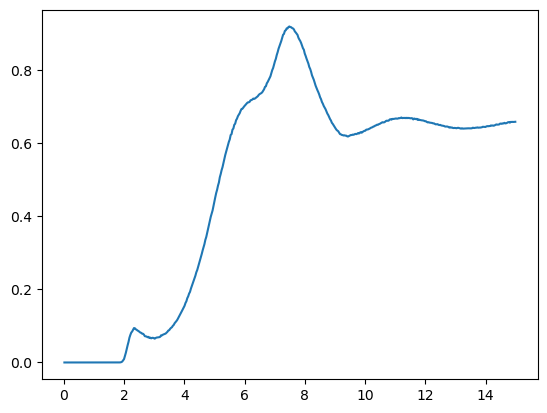

In [27]:
graph = plt.plot(rdf_solv_F_norm.results.bins, rdf_solv_F_norm.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv_F_norm.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])

In [8]:
rdf_solv_F1 = InterRDF(li, solv_F1, nbins=500)
rdf_solv_F1.run()

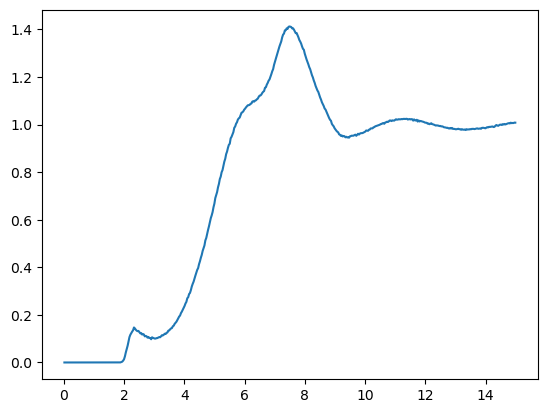

In [9]:
graph = plt.plot(rdf_solv_F1.results.bins, rdf_solv_F1.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv_F1.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])

In [28]:
rdf_solv_O_norm = InterRDF(li, solv_O, nbins=500, norm='density')
rdf_solv_O_norm.run()

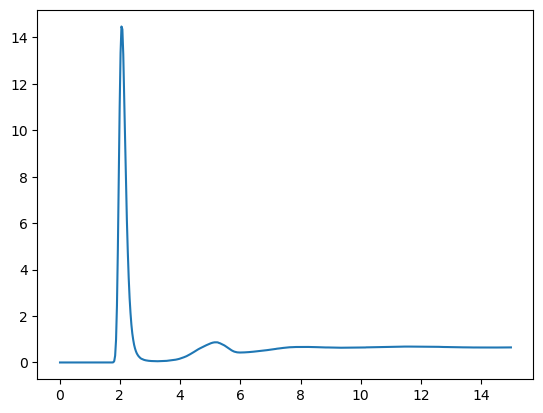

In [29]:
graph = plt.plot(rdf_solv_O_norm.results.bins, rdf_solv_O_norm.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solv_O_norm.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

### RDF between anion & Li+

In [30]:
rdf_salt = InterRDF(li, salt, nbins=500)
rdf_salt.run()

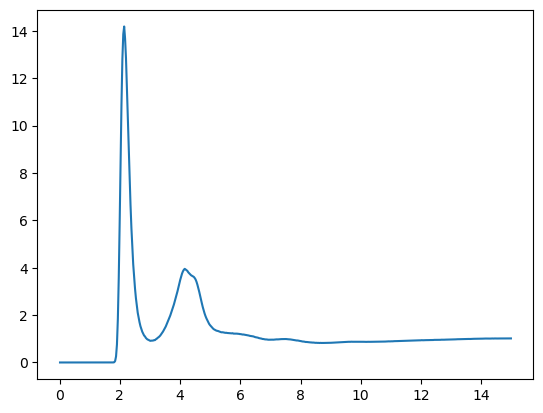

In [31]:
graph = plt.plot(rdf_salt.results.bins, rdf_salt.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_salt_O_F.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])

In [32]:
peaks, _  = find_peaks(-rdf_salt.results.rdf, distance=5)
rdf_salt.results.bins[peaks[0]] ## cut-off for anion

3.0149999999999997

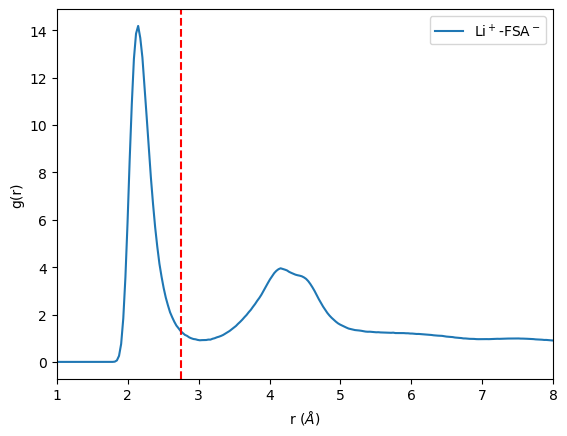

In [36]:
plt.plot(rdf_salt.results.bins, rdf_salt.results.rdf, label='Li$^+$-FSA$^-$')
plt.xlim([1,8])
# plt.axvline(x=rdf_salt.results.bins[peaks[0]], color='red', linestyle='--')
plt.axvline(x=2.75, color='red', linestyle='--')
plt.xlabel('r ($\AA$)')
plt.ylabel('g(r)')
plt.legend()

### RDF between anion-F & solvent-F

In [ ]:
rdf_solvF_saltF = InterRDF(solv_F, salt_F, nbins=500)
rdf_solvF_saltF.run()

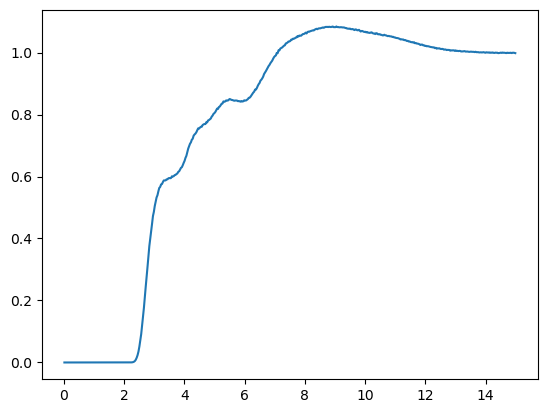

In [16]:
graph = plt.plot(rdf_solvF_saltF.results.bins, rdf_solvF_saltF.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solvF_saltF.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

In [7]:
rdf_solvF_saltF_norm = InterRDF(solv_F, salt_F, nbins=500, norm='density')
rdf_solvF_saltF_norm.run()

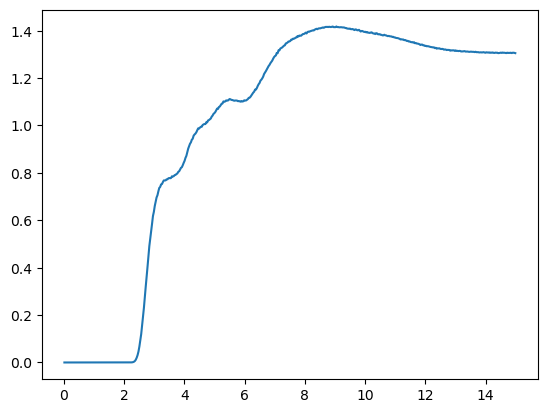

In [8]:
graph = plt.plot(rdf_solvF_saltF_norm.results.bins, rdf_solvF_saltF_norm.results.rdf)
data = graph[0].get_data()
with open('dfethf_Li_solvF_saltF_norm.csv', 'w') as myfile: 
    writer = csv.writer(myfile)
    writer.writerow(['x', 'y'])
    for i in range(len(data[0])): 
        writer.writerow([data[0][i], data[1][i]])  

### Calculate solvation distribution

In [15]:
ani_resname = 'FSI'
solv_resname = 'DFETH'

sols = [ani_resname, solv_resname]
nsols = len(sols)

maxSol = 10
maxAni = 10
counts = np.zeros([maxAni,maxSol])
print(counts)

nFrame = len(u_0.trajectory)
print(nFrame)
# rcuts = 3.0*np.ones(nsols)
rcuts = [2.75, 2.60] # [anion, solvent]
print(rcuts)

dt = 1    ## in ps      
beg = 500.0      ## in ps
matRes = np.zeros((nFrame,1))
print(matRes)
end = len(u_0.trajectory)

solv_res = []
salt_res = []
solv_ctr = []
salt_ctr = []

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
29769
[2.75, 2.6]
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]


In [ ]:
ctr = 0
for ts in u_0.trajectory[int(beg/dt):int(end/dt)]:  ## starts after the beg time defined earlier
    ctr += 1
   # print(ts)
   # print(u.trajectory.time)
   # if (u.trajectory.time > beg) and (u.trajectory.time % dta == 0):      ## somehow this condition is not working
    if  ctr % 50 == 0.0:                                                    ## divisor is the timesteps after which solvation structures are analyzed; change it accordingly
        print(u_0.trajectory.time)
        for a in li.atoms:
            print("***********************************************")
            print(a)
            agLi1=mda.core.groups.AtomGroup([a])
            # nSolRes = np.zeros((nsols,), dtype=int)
            nSolRes = [0 for i in range(nsols)]
            resIDSol = [0 for i in range(nsols)]
            solv_resid = []
            for isol in range(0,nsols):
                si=sols[isol]
                solAtms = u_0.select_atoms("resname {0:5s} and (name O* F*) and around {1:8.3f} group li1".format(si,rcuts[isol]),li1=agLi1)
                solRes = solAtms.residues
                # resIDSol = solRes.resids
                resIDSol[isol] = list(solRes.resids) ## for calculating molecule wise coordination
                # resIDSol[isol] = list(solAtms) ## for calculating atom wise coordination
                print(solAtms)
                nSolRes[isol] = len(resIDSol[isol])
                solv_resid += list(resIDSol[isol])
                print("Frame: {0:5d}, Time: {1:8.3f} ps, # solv_grp: {2:5d} ".format(ts.frame, u_0.trajectory.time, nSolRes[isol]))
#          print("-------------------------------------------------")
            counts[nSolRes[0],nSolRes[1]] += 1.0
            # if nSolRes[0] == 1 and nSolRes[1] == 3:
            #     print(solv_resid)
            #     solv_struc = u_0.atoms.select_atoms('resid {} or resid {} or resid {} or resid {}'.format(a.resid, solv_resid[0], solv_resid[1], solv_resid[2]), periodic=True)
            #     res_solv_struc = solv_struc.residues
            #     res_solv_struc.atoms.write(file_format='pdb', filename='solv-struc/dfethf_{}_{}_{}_{}.pdb'.format(a.resid,ts.frame,nSolRes[0],nSolRes[1]), frames=[ts.frame])
            #     res_solv_struc.atoms.write(file_format='xyz', filename='solv-struc/dfethf_{}_{}_{}_{}.xyz'.format(a.resid,ts.frame,nSolRes[0],nSolRes[1]), frames=[ts.frame])

In [9]:
sumCounts=np.sum(counts)
freqs=counts/sumCounts*100
# print(counts)
print(sumCounts)

conc_salt = 1 ## change it accordingly
file_name = 'solv_dist_' + solv_resname + '_' + ani_resname + '_' + str(conc_salt) + 'M.csv'
fo=open(file_name,"w")
fo.write("anion_number,solvent_number,distribution_percentage\n")

for i1 in range(maxAni):
    for i2 in range(maxSol):
        if freqs[i1,i2]>0.0:
            print("{:5d} {:5d} {:8.3f}".format(i1,i2,freqs[i1,i2]) )
            fo.write("{:5d},{:5d},{:.3f}\n".format(i1,i2,freqs[i1,i2]))
fo.close()

202650.0
    0     1    0.002
    0     2    0.059
    0     3    2.677
    0     4   15.753
    0     5    5.131
    0     6    0.023
    1     0    0.002
    1     1    0.151
    1     2    4.269
    1     3   48.384
    1     4    8.729
    1     5    0.105
    2     0    0.052
    2     1    3.173
    2     2    9.236
    2     3    1.651
    2     4    0.064
    3     0    0.155
    3     1    0.302
    3     2    0.075
    3     3    0.007
    4     2    0.001


### Save correct solvation structures

In [ ]:
ctr = 0
for ts in u_0.trajectory[int(beg/dt):int(end/dt)]:  ## starts after the beg time defined earlier
    ctr += 1
   # print(ts)
   # print(u.trajectory.time)
   # if (u.trajectory.time > beg) and (u.trajectory.time % dta == 0):      ## somehow this condition is not working
    if  ctr % 500 == 0.0:                                                    ## divisor is the timesteps after which solvation structures are analyzed; change it accordingly
        print(u_0.trajectory.time)
        for a in li.atoms:
            print("***********************************************")
            print(a)
            agLi1=mda.core.groups.AtomGroup([a])
            # nSolRes = np.zeros((nsols,), dtype=int)
            nSolRes = [0 for i in range(nsols)]
            resIDSol = [0 for i in range(nsols)]
            solv_resid = []
            for isol in range(0,nsols):
                si=sols[isol]
                solAtms = u_0.select_atoms("resname {0:5s} and (name O* F*) and around {1:8.3f} group li1".format(si,rcuts[isol]),li1=agLi1)
                solRes = solAtms.residues
                # resIDSol = solRes.resids
                resIDSol[isol] = list(solRes.resids) ## for calculating molecule wise coordination
                # resIDSol[isol] = list(solAtms) ## for calculating atom wise coordination
                print(solAtms)
                nSolRes[isol] = len(resIDSol[isol])
                solv_resid += list(resIDSol[isol])
                print("Frame: {0:5d}, Time: {1:8.3f} ps, # solv_grp: {2:5d} ".format(ts.frame, u_0.trajectory.time, nSolRes[isol]))
                # print("-------------------------------------------------")
            counts[nSolRes[0],nSolRes[1]] += 1.0
            if nSolRes[0] == 1 and nSolRes[1] == 3:
                print(solv_resid)
                solv_struc = u_0.atoms.select_atoms('resid {} or resid {} or resid {} or resid {} or resid {}'.format(a.resid, solv_resid[0], solv_resid[1], solv_resid[2], solv_resid[3]), periodic=True)
                # Apply minimum image convention
                box = u_0.dimensions[:3]
                li_pos = a.position
                
                for atom in solv_struc.atoms:
                    if atom.resid != a.resid:
                        delta = atom.position - li_pos
                        # Apply minimum image convention
                        delta = delta - box * np.round(delta / box)
                        atom.position = li_pos + delta
                
                solv_struc.write('solv-struc/dfethf_{}_{}_{}_{}.pdb'.format(
                    a.resid, ts.frame, nSolRes[0], nSolRes[1]
                ))

In [ ]:
view = nv.show_mdanalysis(solv_struc) ## does not show transformed structure => how to show transformed structure??

view

NGLWidget(max_frame=29768)